# Study 71 — Ambush 🪤
### Four S&P 500 edges died paying the spread. What if you only trade the days they all fire at once?

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Rarity defeats costs?: Confirmed](https://img.shields.io/badge/Rarity_defeats_costs%3F-Confirmed-8b949e?style=flat-square)

This bench spent seventy studies watching short-term stock-market edges die the same death: the pattern is real, but it trades so often that the bid-ask spread eats it alive. This study flips the logic — keep four of those dead edges as *filters*, stay out of the market almost always, and strike only on the rare day they agree. Rarity, not signal strength, is the cost defence.

> 📓 **This is the plain-language layer.** Want the statistics, the bootstrap and the cost maths? That's the companion notebook, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** An educational, reproducible research tool: every chart below is generated by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))        # the study package (ambush/)
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

from ambush import data, signals, strategy
from quantlab.repro import DEFAULT_AS_OF, as_of, fingerprint

spy = as_of(data.spy_frame())
vix = as_of(data.vix_series().to_frame())["vix"]
rf  = as_of(data.rf_series().to_frame())["rf"]
print(f"SPY {spy.index.min().date()} -> {spy.index.max().date()} ({len(spy)} sessions), "
      f"as-of {DEFAULT_AS_OF}")
print("fingerprints:", fingerprint(spy.round(6)), "/", fingerprint(vix.to_frame().round(6)))


SPY 1993-01-29 -> 2026-06-01 (8391 sessions), as-of 2026-06-01
fingerprints: 68198e0c321b / 1d63caa5b039


## The answer first 🎯

| Question | Answer |
|---|---|
| Is the confluence premium real? | **Yes** — a ≥3-signal day is followed by **+19.6 bp** next session vs +0.55 bp on a quiet day, and the climb is perfectly monotone |
| Did it fade like its ingredients? | **No** — +17.6 → +15.3 bp/day across 2015, statistically indistinguishable |
| Does rarity beat the spread? | **Yes** — ~15 trades/yr leave costs eating only ~a quarter of the gross (the daily version of these edges lost *everything* to costs) |
| So… can you get rich? | **Not so fast** — in market only 8% of days under a strict 1%/day risk budget, it earns **+1.23%/yr** over cash. A real edge, honestly small |

The rest of this notebook is *why* you should believe each line.

## 1 · The claim

Markets keep a little mean-reversion kindness for whoever provides liquidity on ugly days: buy when a day closes crushed at the bottom of its range ([study 19](../../19-rubber-band/)), around the turn of the month ([study 42](../../42-last-call/)), after a red close ([study 13](../../13-crimson-hour/)), when the VIX is jumpy ([study 03](../../03-fear-gauge/)). Each of those is *real* in the data — and each one, traded alone, **lost money net** because it trades almost every day and the spread never sleeps. The ambush claim: those four edges share the same fingerprint (panicky selling that overshoots), so the day **three or four fire together** should carry their *stacked* premium — and such days are rare enough that costs can't reach them.

## 2 · So what?

If true, it's the first strategy this bench has met where the *cost problem is solved by design* instead of wished away. And it's exactly the shape a small CFD account can trade: no contract-size constraint, one liquid instrument (US500), a couple of trades a month, every position sized so a bad day costs at most **1% of the account**. If false, we've shown that stacking dead edges just makes a deader edge — also worth knowing, since 'combine weak signals' is the most common retail fantasy (and [study 38](../../38-chorus/) already showed *averaging* them adds nothing).

## 3 · How would we even know?

Everything was frozen **before** the test, in writing ([docs/preregistration.md](../docs/preregistration.md)): the four definitions and their thresholds (all inherited from the source studies — nothing tuned here), the confluence rule (long only, K≥3, family K∈{1..4} declared and statistically corrected for), the CFD cost model (1 bp one-way + financing over cash), the risk overlay (vol targeting, 1%/day budget, intraday stop), the 2015 in/out-of-sample split, and the exact criteria for each verdict stamp. The harness also had to pass a lie-detector first: it must *find* a premium planted in a synthetic tape, and find *nothing* in a random walk (it does — `examples/run_synthetic_demo.py`).

## 4 · The teardown — let's actually look

First exhibit: line up every trading day since 1993 by how many of the four signals fired at its close, and ask what SPY did *the next day*. No sizing, no costs — just the raw ladder.

,next_bps,n,share
count,,,
0,0.550,3392,0.400
1,1.910,2772,0.330
2,9.210,1590,0.190
3,17.180,574,0.070
4,42.190,62,0.010


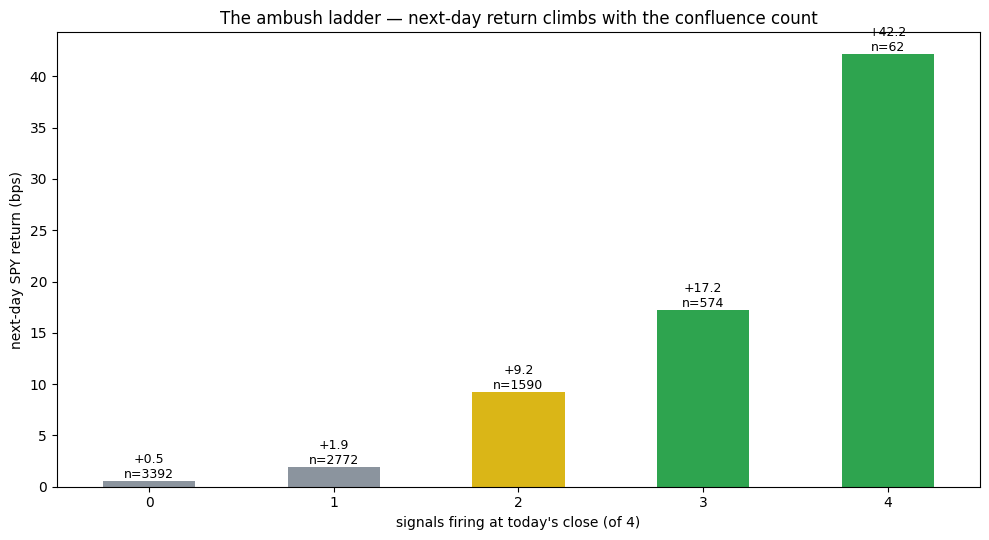

In [2]:
lift = strategy.lift_table(spy, vix)
display(lift.round(2))

ax = lift["next_bps"].plot.bar(color=["#8b949e"]*2 + ["#dab617"] + ["#2ea44f"]*2, rot=0)
ax.set_xlabel("signals firing at today's close (of 4)")
ax.set_ylabel("next-day SPY return (bps)")
ax.set_title("The ambush ladder — next-day return climbs with the confluence count")
for i, (v, n) in enumerate(zip(lift["next_bps"], lift["n"])):
    ax.annotate(f"{v:+.1f}\nn={n}", (i, v), ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()


A quiet day is worth half a basis point the next morning. A four-alarm day is worth **+42.2 bp** — eighty times more. The climb is perfectly ordered, on 8,391 sessions of real tape.

🔬 *For the quants:* the armed stream clears the bench's robust-inference bar — HAC *t* = **+3.06** at K≥3 — and White's Reality Check across every K we announced puts the family at **p = 0.009**. Details next door.

Second exhibit: has it rotted, like every ingredient did on its own?

In [3]:
dec = strategy.premium_change(spy, vix, k=3, split="2015")
print(f"armed-day premium over the rest: {dec['premium_pre_bp']:+.1f} bp/day before 2015 "
      f"(Welch t {dec['welch_t_pre']:+.2f}) -> {dec['premium_post_bp']:+.1f} bp/day since "
      f"(t {dec['welch_t_post']:+.2f})")
print(f"test of the *difference*: t_change = {dec['t_change']:+.2f}  ->  no detectable decay")


armed-day premium over the rest: +17.6 bp/day before 2015 (Welch t +2.07) -> +15.3 bp/day since (t +1.32)
test of the *difference*: t_change = +0.17  ->  no detectable decay


Now the part that kills most paper edges — make it a *book*. Long only on confluence days, vol-targeted size, a hard stop at −1% of the account, 1 bp spread each way plus overnight financing, cash earning the T-bill the rest of the time. Raced fairly against just *holding* SPY (both measured over cash):

,sharpe,excess/yr,time in mkt,trades/yr,OOS sharpe
book,,,,,
K>=1,0.351,0.024,0.594,52.833,0.350
K>=2,0.408,0.020,0.265,43.762,0.405
K>=3,0.424,0.012,0.076,15.078,0.278
K>=4,0.284,0.002,0.007,1.772,0.006
SPY B&H (excess),0.420,0.078,1.000,0.000,0.622


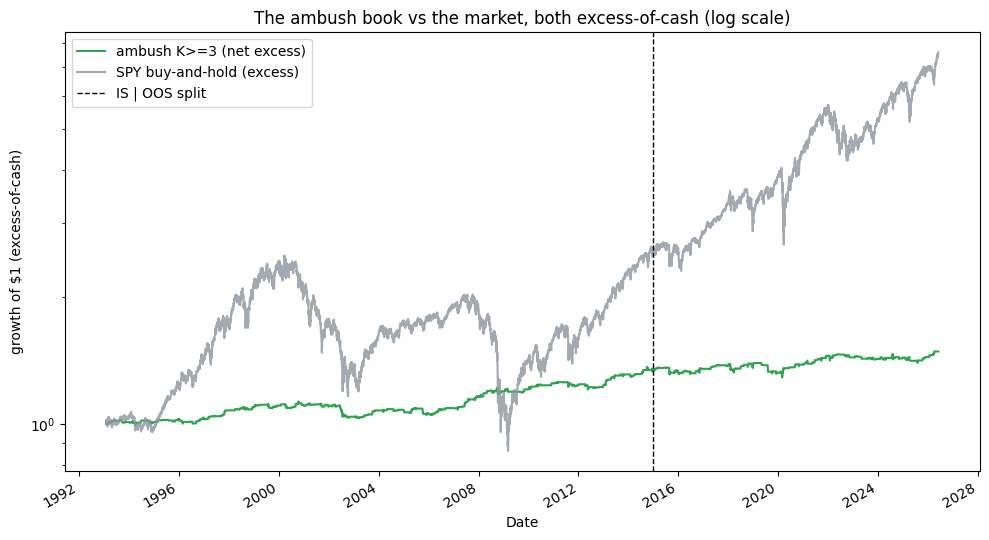

In [4]:
rows, curves = [], {}
for k in (1, 2, 3, 4):
    led = strategy.book(spy, vix, rf, k=k)
    s  = strategy.summary(led["net_excess"], led)
    so = strategy.summary(led["net_excess"]["2015":], led["2015":])
    rows.append({"book": f"K>={k}", "sharpe": s["sharpe"], "excess/yr": s["ann_excess"],
                 "time in mkt": s["time_in_market"], "trades/yr": s["trades_per_year"],
                 "OOS sharpe": so["sharpe"]})
    curves[f"K>={k}"] = (1 + led["net_excess"]).cumprod()
bh = strategy.bh_excess(spy, rf)
rows.append({"book": "SPY B&H (excess)", "sharpe": strategy.summary(bh)["sharpe"],
             "excess/yr": strategy.summary(bh)["ann_excess"], "time in mkt": 1.0,
             "trades/yr": 0, "OOS sharpe": strategy.summary(bh["2015":])["sharpe"]})
display(pd.DataFrame(rows).set_index("book").round(3))

ax = curves["K>=3"].plot(label="ambush K>=3 (net excess)", color="#2ea44f")
(1 + bh).cumprod().plot(ax=ax, label="SPY buy-and-hold (excess)", color="#8b949e", alpha=0.8)
ax.axvline(pd.Timestamp("2015-01-01"), ls="--", c="k", lw=1, label="IS | OOS split")
ax.set_yscale("log"); ax.legend(); ax.set_ylabel("growth of $1 (excess-of-cash)")
ax.set_title("The ambush book vs the market, both excess-of-cash (log scale)")
plt.tight_layout(); plt.show()


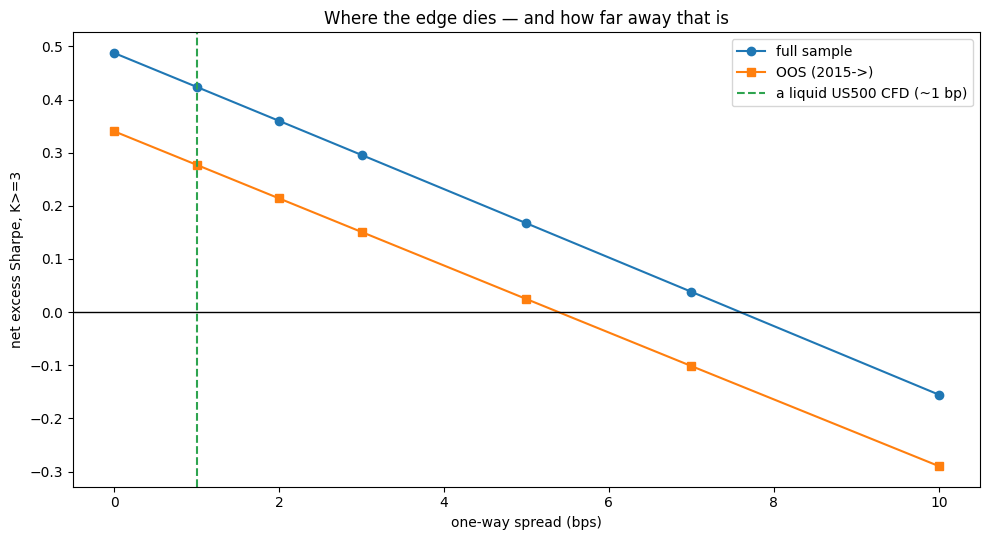

In [5]:
sw_full = strategy.cost_sweep(spy, vix, rf)
sw_oos  = strategy.cost_sweep(spy["2014-10":], vix, rf)   # 3-month warm-up for the vol estimator
ax = sw_full["net_sharpe"].plot(marker="o", label="full sample")
sw_oos["net_sharpe"].plot(ax=ax, marker="s", label="OOS (2015->)")
ax.axhline(0, c="k", lw=1); ax.axvline(1.0, ls="--", c="#2ea44f", label="a liquid US500 CFD (~1 bp)")
ax.set_xlabel("one-way spread (bps)"); ax.set_ylabel("net excess Sharpe, K>=3")
ax.set_title("Where the edge dies — and how far away that is")
ax.legend(); plt.tight_layout(); plt.show()


## 5 · The verdict

**Signal `REAL`** — the ladder is monotone, the K≥3 premium carries HAC *t* = +3.06, the family is multiple-testing-corrected, and the premium hasn't faded.

**Tradability `FRAGILE`** — the book survives costs with a wide moat (break-even ~7 bp vs ~1 bp real), but it spends 8% of its life in the market and earns +1.23%/yr over cash. Out-of-sample its Sharpe is **+0.28** — positive, but below the **0.30** bar we froze in advance, with a confidence interval that still touches zero. We called that FRAGILE before we knew the number; it stays FRAGILE.

**Rarity defeats costs? `CONFIRMED`** — the design goal, and the study's actual discovery: the same ingredients that lose >100% of their edge to costs traded daily keep ~75% of it traded ~15×/yr.

## 6 · Could you actually trade it?

Mechanically, yes — that's what it was designed for. One liquid instrument, signals computable at the close in a spreadsheet, ~15 entries a year, position small (median ~0.5× the account), a stop that fires twice a year, and a worst 33-year drawdown of −9% on the excess line. The honest catch is the *prize*: ~1.2%/yr over cash on its own is dinner money, not a living — it only makes sense **stacked on top of** whatever else the account does (it's flat 92% of the time, so it stacks cleanly). And the 1% budget holds *at the stop*: an overnight gap straight through it can cost more (worst real day: −2.6%). CFDs add a second honest catch: the quoted spread is the *good* case — weekend financing, widened spreads at the close, and your broker's hedging all tax the same ~20 bp/trade edge.

## 7 · Going further 🚪

- **The natural upgrade** — intraday entries (buy the stop-run at 15:50, not the close) would need minute bars; the bench's daily tape can't see it.
- **A fifth ingredient** — overnight-only holding ([study 01](../../01-overnight-anomaly/)) on armed days: exit at the open, halve the financing.
- **Fork it** — every threshold is one constant in [`ambush/signals.py`](../ambush/signals.py); the pre-registration tells you exactly which knobs were *not* allowed to move, so you know what an honest variant looks like.

*Reproduce: `python examples/verify.py` (offline, fingerprinted) · machinery proof: `python examples/run_synthetic_demo.py` · full numbers: [docs/results.md](../docs/results.md).*